# Experiment 5: Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Model:** MobileNetV2 (ImageNet pretrained) &nbsp;|&nbsp; **Dataset:** Oxford-IIIT Pet Dataset (37 breeds)

#### Setup: Imports and Configuration

In [3]:
# Core imports
import os
import gc
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
DATA_DIR = "/kaggle/working/data"          # writable location on Kaggle
IMG_SIZE = 224
NUM_WORKERS = 2                             # set to 0 if you see worker/memory issues
PIN_MEMORY = torch.cuda.is_available()

BATCH_SIZE = 32                             # default batch size (also tuned in Section 9)

# NOTE: every experiment in this notebook (weight init, regularization, optimizers,
# hyperparameter sweeps, transfer learning, k-fold cross-validation and the final model)
# is trained on the FULL Oxford-IIIT Pet training/validation split

os.makedirs(DATA_DIR, exist_ok=True)


Using device: cuda


In [5]:
def free_memory(*objs):
    """Delete references and aggressively free GPU/CPU memory.
    Call this after every experiment/model so that dozens of small
    training runs don't accumulate and crash the kernel."""
    for o in objs:
        try:
            del o
        except NameError:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


#### Task 1: Dataset Preparation (Oxford-IIIT Pet Dataset)

Images are RGB, resized to 224x224x3 and normalized using the ImageNet mean/std (required
since we use an ImageNet-pretrained MobileNetV2). We keep a strictly separate
train / validation / test split, and the test split is **never** touched until Section 12.

In [6]:
# ImageNet normalization statistics (required for pretrained MobileNetV2)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Transform used only for displaying raw sample images (no normalization)
display_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


In [7]:
# Download once (label-only pass) to get stratified train/validation indices
raw_trainval = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="trainval", target_types="category", download=True
)
labels = raw_trainval._labels
classes = raw_trainval.classes
num_classes = len(classes)
print("Number of breeds (classes):", num_classes)
print("Trainval images:", len(labels))


100%|██████████| 792M/792M [01:13<00:00, 10.8MB/s]  
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.07MB/s]


Number of breeds (classes): 37
Trainval images: 3680


In [8]:
# Stratified train / validation split (80 / 20) on the trainval set
all_indices = list(range(len(labels)))
train_idx, val_idx = train_test_split(
    all_indices, test_size=0.2, stratify=labels, random_state=SEED
)
print("Full training indices  :", len(train_idx))
print("Full validation indices:", len(val_idx))

# Two dataset views over the SAME images (only the transform differs), so a Subset
# built from either one refers to the same underlying files -- no data is duplicated.
train_dataset_full = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="trainval", target_types="category", transform=train_transform
)
eval_dataset_full = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="trainval", target_types="category", transform=eval_transform
)
display_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="trainval", target_types="category", transform=display_transform
)

train_subset_full = Subset(train_dataset_full, train_idx)
val_subset_full   = Subset(eval_dataset_full, val_idx)

# Independent test set -- kept untouched until Section 12
test_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="test", target_types="category", transform=eval_transform, download=True
)
print("Test images:", len(test_dataset))


Full training indices  : 2944
Full validation indices: 736
Test images: 3669


In [9]:
# Full train / validation / test DataLoaders -- used by EVERY experiment in this notebook
# (weight init, regularization, optimizers, hyperparameter sweeps, transfer learning,
# k-fold cross-validation and the final model).
train_labels_arr = np.array(labels)[train_idx]
val_labels_arr   = np.array(labels)[val_idx]

train_loader = DataLoader(train_subset_full, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_subset_full, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Training images  :", len(train_subset_full))
print("Validation images:", len(val_subset_full))
print("Test images       :", len(test_dataset))


Training images  : 2944
Validation images: 736
Test images       : 3669


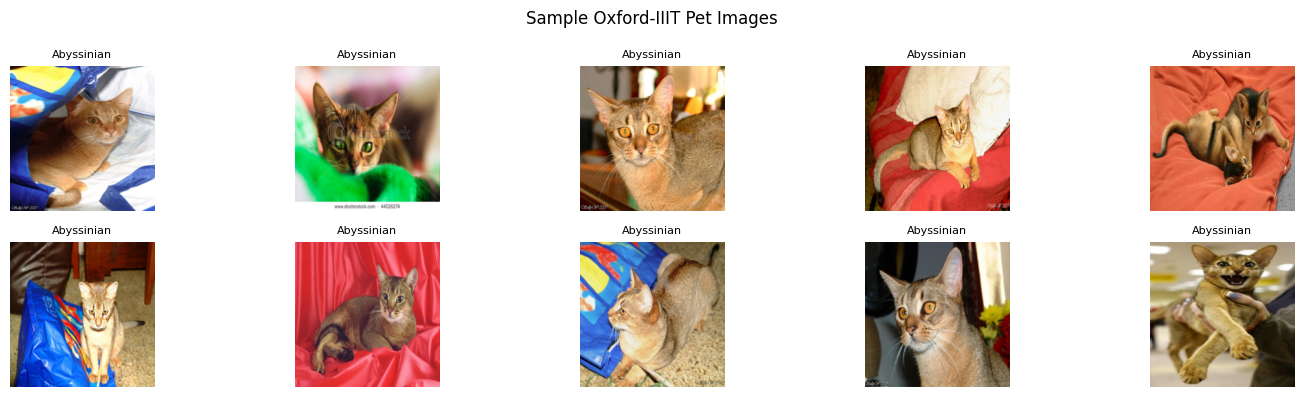

In [10]:
# Display sample images
plt.figure(figsize=(15, 4))
for i in range(10):
    image, label = display_dataset[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(classes[label], fontsize=8)
    plt.axis("off")
plt.suptitle("Sample Oxford-IIIT Pet Images")
plt.tight_layout()
plt.show()


#### Model: MobileNetV2 Transfer-Learning Wrapper

A single reusable model class wraps a pretrained MobileNetV2. The convolutional
`features` block can be frozen (feature extraction) or partially unfrozen (fine-tuning).
The classifier head is configurable so the **same class** can be reused for every study
below (weight initialization, regularization/Dropout/BatchNorm, optimizers, hyperparameter
tuning, transfer learning and k-fold cross-validation) simply by changing its arguments.

In [11]:
class PetClassifier(nn.Module):
    """MobileNetV2 backbone (ImageNet-pretrained) + configurable classifier head.

    Parameters
    ----------
    num_classes : number of output classes (37 pet breeds)
    dropout     : dropout probability in the head (0 disables Dropout)
    use_bn      : whether to add a BatchNorm1d layer in the head
    freeze_base : if True, all convolutional (feature) layers are frozen
    """

    def __init__(self, num_classes=37, dropout=0.5, use_bn=False, freeze_base=True):
        super().__init__()
        backbone = torchvision.models.mobilenet_v2(
            weights=torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
        )
        self.features = backbone.features          # convolutional feature extractor
        self.feature_dim = backbone.last_channel    # 1280 for MobileNetV2

        for p in self.features.parameters():
            p.requires_grad = not freeze_base

        self.pool = nn.AdaptiveAvgPool2d(1)

        head_layers = [nn.Flatten()]
        if use_bn:
            head_layers.append(nn.BatchNorm1d(self.feature_dim))
        head_layers.append(nn.Linear(self.feature_dim, 256))
        head_layers.append(nn.ReLU())
        if dropout and dropout > 0:
            head_layers.append(nn.Dropout(dropout))
        head_layers.append(nn.Linear(256, num_classes))

        self.classifier = nn.Sequential(*head_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

    def unfreeze_last_n_blocks(self, n=3):
        """Unfreeze the last n child blocks of the MobileNetV2 feature extractor
        (used for fine-tuning, Section 10 / Case B)."""
        total = len(self.features)
        for idx, block in enumerate(self.features):
            if idx >= total - n:
                for p in block.parameters():
                    p.requires_grad = True

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_parameter_count(self):
        return sum(p.numel() for p in self.parameters())


In [12]:
def apply_weight_init(model, method="he"):
    """Initialize the Linear layers of the classifier head.
    The pretrained convolutional backbone is left untouched -- initialization is only
    meaningful for the newly-added, randomly-created classifier layers."""
    for m in model.classifier.modules():
        if isinstance(m, nn.Linear):
            if method == "zero":
                nn.init.zeros_(m.weight)
            elif method == "random":
                # naive / un-scaled random initialization
                nn.init.normal_(m.weight, mean=0.0, std=1.0)
            elif method == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif method == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            else:
                raise ValueError(f"Unknown init method: {method}")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model


def build_model(init_method="he", dropout=0.5, use_bn=False, freeze_base=True, num_classes=None):
    model = PetClassifier(num_classes=num_classes or num_classes_global,
                           dropout=dropout, use_bn=use_bn, freeze_base=freeze_base)
    apply_weight_init(model, method=init_method)
    return model.to(device)


def make_optimizer(model, name="adam", lr=1e-3, momentum=0.9, weight_decay=0.0):
    params = filter(lambda p: p.requires_grad, model.parameters())
    if name == "sgd":
        return optim.SGD(params, lr=lr, weight_decay=weight_decay)
    elif name == "momentum":
        return optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif name == "rmsprop":
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    elif name == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {name}")


num_classes_global = num_classes


In [13]:
def train_eval(model, optimizer, train_loader, val_loader, epochs, verbose=False):
    """Train `model` and evaluate on `val_loader` every epoch.
    Returns a history dict of python floats (never keeps tensors/graphs around) plus
    the total wall-clock training time in seconds."""
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    start_time = time.time()
    for epoch in range(epochs):
        # ---------------- Training ----------------
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100.0 * correct / total

        # ---------------- Validation ----------------
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = 100.0 * val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"  Epoch {epoch+1}/{epochs} | train_loss={train_loss:.3f} train_acc={train_acc:.2f}% "
                  f"| val_loss={val_loss:.3f} val_acc={val_acc:.2f}%")

    elapsed = time.time() - start_time
    return history, elapsed


#### Task 2: Weight Initialization

We compare four initialization strategies for the newly-added classifier head (the
pretrained convolutional backbone stays frozen and unchanged): **Zero**, **Random**
(naive/un-scaled normal), **Xavier/Glorot**, and **He**. Each is trained on the full
training/validation split for a fixed number of epochs with a fixed optimizer (Adam) so
that only the initialization changes between runs.


In [14]:
INIT_EPOCHS = 10 
init_methods = ["zero", "random", "xavier", "he"]
init_histories = {}

for method in init_methods:
    print(f"Training with '{method}' initialization...")
    model = build_model(init_method=method, dropout=0.5, use_bn=False, freeze_base=True)
    optimizer = make_optimizer(model, name="adam", lr=1e-3)

    history, elapsed = train_eval(model, optimizer, train_loader, val_loader, INIT_EPOCHS)
    init_histories[method] = history
    print(f"  -> final val_acc={history['val_acc'][-1]:.2f}% | time={elapsed:.1f}s\n")

    free_memory(model, optimizer)


Training with 'zero' initialization...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 197MB/s]


  -> final val_acc=2.72% | time=106.1s

Training with 'random' initialization...
  -> final val_acc=5.84% | time=107.2s

Training with 'xavier' initialization...
  -> final val_acc=90.08% | time=106.1s

Training with 'he' initialization...
  -> final val_acc=88.72% | time=106.5s



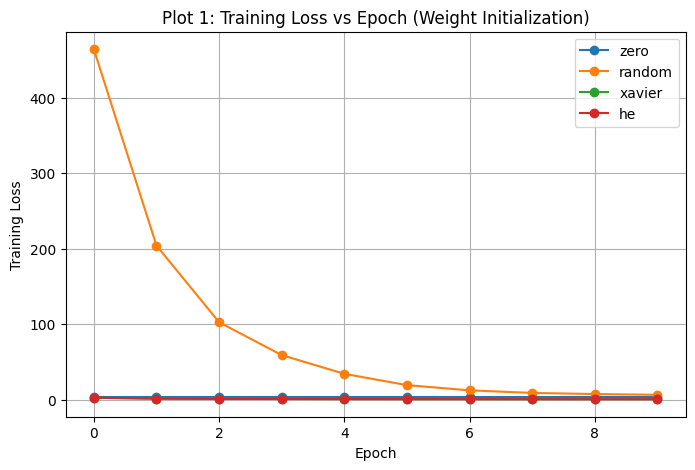

In [15]:
# Plot 1: Training Loss vs Epoch (per initialization method)
plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(init_histories[method]["train_loss"], marker='o', label=method)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 1: Training Loss vs Epoch (Weight Initialization)")
plt.legend()
plt.grid(True)
plt.show()


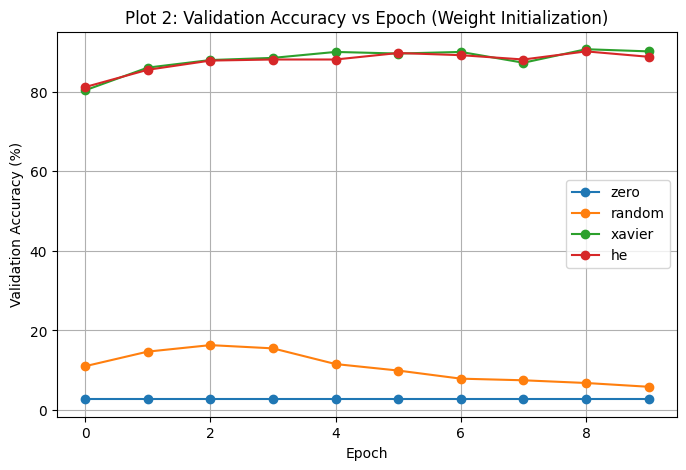

Best initialization method: xavier


In [16]:
# Plot 2: Validation Accuracy vs Epoch (per initialization method)
plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(init_histories[method]["val_acc"], marker='o', label=method)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 2: Validation Accuracy vs Epoch (Weight Initialization)")
plt.legend()
plt.grid(True)
plt.show()

best_init = max(init_methods, key=lambda m: init_histories[m]["val_acc"][-1])
print("Best initialization method:", best_init)


#### Task 3: Regularization and Overfitting

We compare **No Regularization**, **L2 (weight decay)**, **Dropout**, and **Batch
Normalization**, all trained on the full training/validation split using the fixed `he`
initialization and Adam optimizer, changing only the regularization setting between runs.
Training for a longer horizon (`REG_EPOCHS`) gives the generalization gap enough time to
become visible even though only the classifier head (a few hundred thousand parameters) is
being trained against thousands of images.


In [17]:
REG_EPOCHS = 20

reg_configs = {
    "No Regularization": dict(dropout=0.0, use_bn=False, weight_decay=0.0),
    "L2":                dict(dropout=0.0, use_bn=False, weight_decay=1e-3),
    "Dropout":            dict(dropout=0.5, use_bn=False, weight_decay=0.0),
    "BatchNorm":          dict(dropout=0.0, use_bn=True,  weight_decay=0.0),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"Training with '{name}'...")
    model = build_model(init_method="he", dropout=cfg["dropout"], use_bn=cfg["use_bn"], freeze_base=True)
    optimizer = make_optimizer(model, name="adam", lr=1e-3, weight_decay=cfg["weight_decay"])

    history, elapsed = train_eval(model, optimizer, train_loader, val_loader, REG_EPOCHS)
    reg_histories[name] = history
    gap = history["train_acc"][-1] - history["val_acc"][-1]
    print(f"  -> final train_acc={history['train_acc'][-1]:.2f}% val_acc={history['val_acc'][-1]:.2f}% "
          f"(gap={gap:.2f} pts) | time={elapsed:.1f}s\n")

    free_memory(model, optimizer)


Training with 'No Regularization'...
  -> final train_acc=98.27% val_acc=87.77% (gap=10.50 pts) | time=211.6s

Training with 'L2'...
  -> final train_acc=98.03% val_acc=88.32% (gap=9.71 pts) | time=211.4s

Training with 'Dropout'...
  -> final train_acc=90.42% val_acc=88.72% (gap=1.70 pts) | time=211.5s

Training with 'BatchNorm'...
  -> final train_acc=98.54% val_acc=87.23% (gap=11.31 pts) | time=211.6s



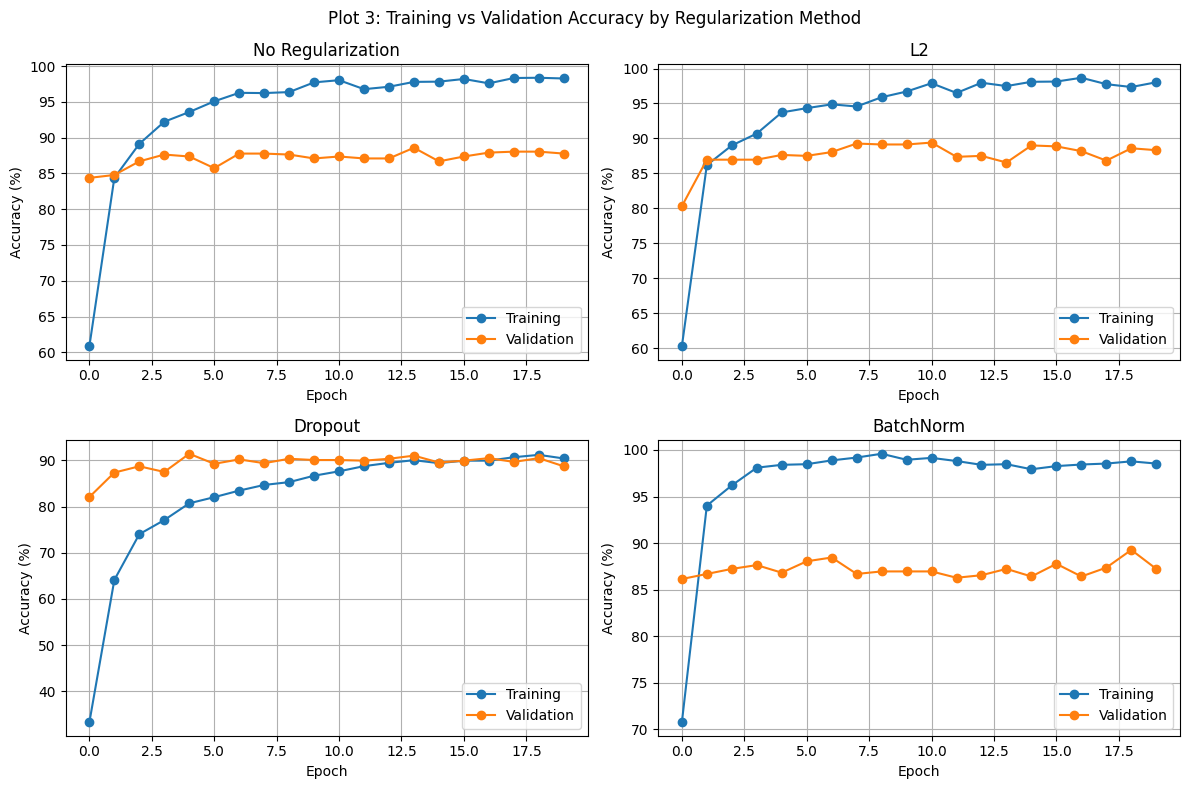

In [18]:
# Plot 3: Training and Validation Accuracy vs Epoch (per regularization setting)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, hist) in zip(axes.flatten(), reg_histories.items()):
    ax.plot(hist["train_acc"], marker='o', label="Training")
    ax.plot(hist["val_acc"], marker='o', label="Validation")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()
    ax.grid(True)
plt.suptitle("Plot 3: Training vs Validation Accuracy by Regularization Method")
plt.tight_layout()
plt.show()


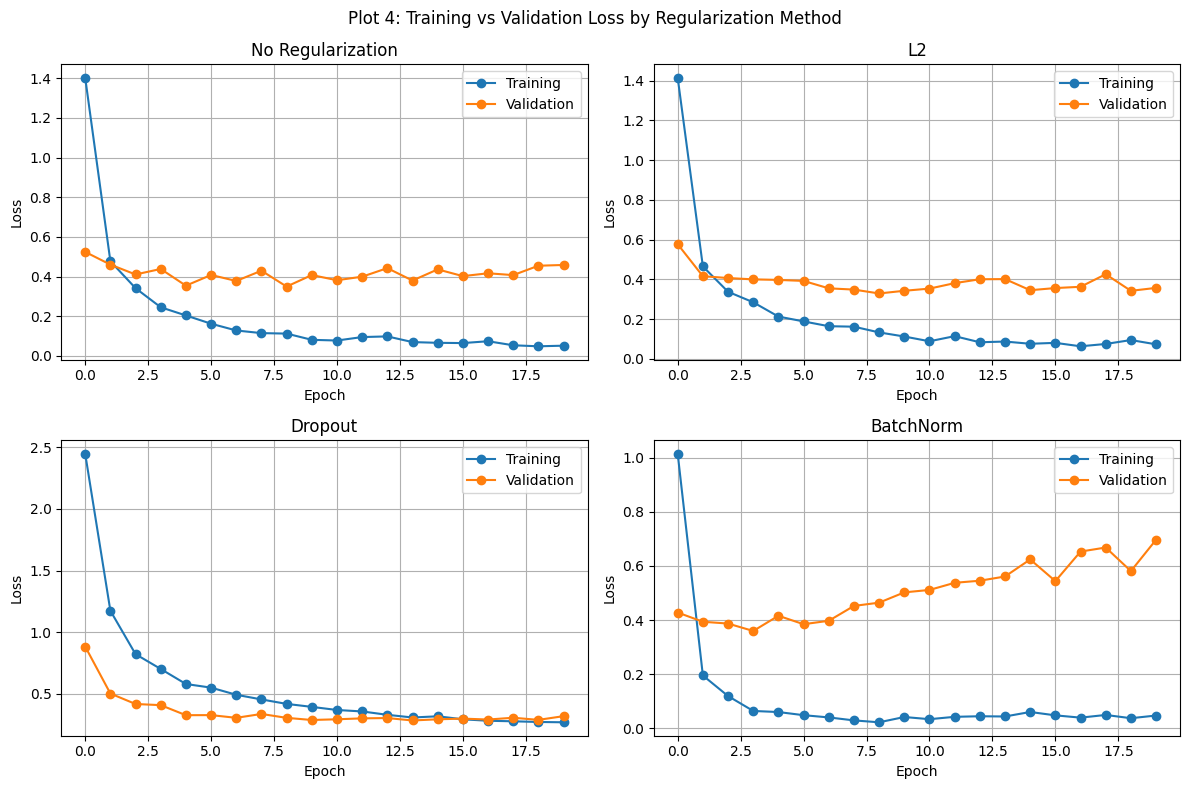

Smallest generalization gap: Dropout


In [19]:
# Plot 4: Training and Validation Loss vs Epoch (per regularization setting)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, hist) in zip(axes.flatten(), reg_histories.items()):
    ax.plot(hist["train_loss"], marker='o', label="Training")
    ax.plot(hist["val_loss"], marker='o', label="Validation")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)
plt.suptitle("Plot 4: Training vs Validation Loss by Regularization Method")
plt.tight_layout()
plt.show()

best_reg = min(reg_configs.keys(),
               key=lambda n: reg_histories[n]["train_acc"][-1] - reg_histories[n]["val_acc"][-1])
print("Smallest generalization gap:", best_reg)


#### Task 4: Batch Normalization

**Numerical example** (matches the manual calculation in the lab sheet): for a mini-batch
$x = [2, 4, 6, 8]$, we compute the batch mean $\mu_B$, batch variance $\sigma_B^2$, and the
normalized activations $\hat{x}_i = \dfrac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$.

In [20]:
# Numerical Batch Normalization example
x = np.array([2.0, 4.0, 6.0, 8.0])
eps = 1e-8

mu_B = x.mean()
sigma2_B = ((x - mu_B) ** 2).mean()
x_hat = (x - mu_B) / np.sqrt(sigma2_B + eps)

gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"Batch mean (mu_B)      : {mu_B}")
print(f"Batch variance (sigma^2): {sigma2_B}")
print(f"Normalized x_hat        : {np.round(x_hat, 3)}")
print(f"Output y (gamma=1,beta=0): {np.round(y, 3)}")


Batch mean (mu_B)      : 5.0
Batch variance (sigma^2): 5.0
Normalized x_hat        : [-1.342 -0.447  0.447  1.342]
Output y (gamma=1,beta=0): [-1.342 -0.447  0.447  1.342]


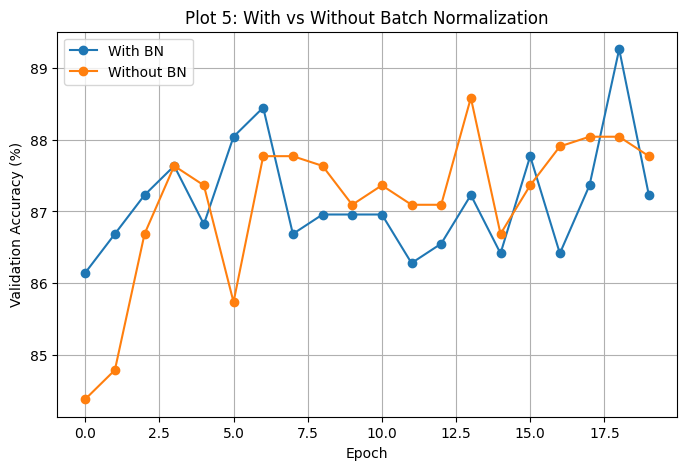

In [21]:
# Plot 5: With vs Without Batch Normalization (reusing Task 3 runs)
plt.figure(figsize=(8, 5))
plt.plot(reg_histories["BatchNorm"]["val_acc"], marker='o', label="With BN")
plt.plot(reg_histories["No Regularization"]["val_acc"], marker='o', label="Without BN")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 5: With vs Without Batch Normalization")
plt.legend()
plt.grid(True)
plt.show()


#### Task 5: Optimization Algorithms

We compare **SGD**, **SGD+Momentum**, **RMSProp**, and **Adam**, all starting from the same
`he`-initialized head, trained on the full training/validation split.


In [22]:
OPT_EPOCHS = 12
CONVERGENCE_TOL = 1.0  # percentage points from the run's own best val_acc

optimizer_configs = {
    "SGD":       dict(name="sgd",      lr=1e-2),
    "Momentum":  dict(name="momentum", lr=1e-2, momentum=0.9),
    "RMSProp":   dict(name="rmsprop",  lr=1e-3),
    "Adam":      dict(name="adam",     lr=1e-3),
}

opt_histories = {}
opt_summary_rows = []

for opt_name, cfg in optimizer_configs.items():
    print(f"Training with optimizer '{opt_name}'...")
    model = build_model(init_method="he", dropout=0.5, use_bn=False, freeze_base=True)
    optimizer = make_optimizer(model, **cfg)

    history, elapsed = train_eval(model, optimizer, train_loader, val_loader, OPT_EPOCHS)
    opt_histories[opt_name] = history

    best_val_acc = max(history["val_acc"])
    # first epoch (1-indexed) at which val_acc gets within CONVERGENCE_TOL points of the best
    epoch_to_converge = next(
        i + 1 for i, acc in enumerate(history["val_acc"]) if acc >= best_val_acc - CONVERGENCE_TOL
    )

    opt_summary_rows.append({
        "Optimizer": opt_name,
        "Final Loss": round(history["train_loss"][-1], 4),
        "Best Val. Accuracy (%)": round(best_val_acc, 2),
        "Epoch to Converge": epoch_to_converge,
        "Time (s)": round(elapsed, 1),
    })
    print(f"  -> best_val_acc={best_val_acc:.2f}% | time={elapsed:.1f}s\n")

    free_memory(model, optimizer)

opt_summary_df = pd.DataFrame(opt_summary_rows)
opt_summary_df


Training with optimizer 'SGD'...
  -> best_val_acc=89.81% | time=125.8s

Training with optimizer 'Momentum'...
  -> best_val_acc=90.49% | time=127.7s

Training with optimizer 'RMSProp'...
  -> best_val_acc=91.58% | time=127.9s

Training with optimizer 'Adam'...
  -> best_val_acc=91.44% | time=128.0s



,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,0.6722,89.81,9,125.8
1,Momentum,0.3494,90.49,6,127.7
2,RMSProp,0.4812,91.58,12,127.9
3,Adam,0.3686,91.44,8,128.0


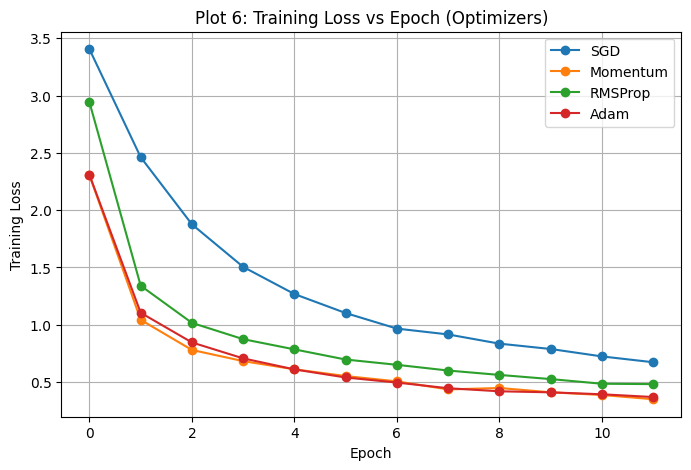

In [23]:
# Plot 6: Training Loss vs Epoch for Different Optimizers
plt.figure(figsize=(8, 5))
for name in optimizer_configs:
    plt.plot(opt_histories[name]["train_loss"], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 6: Training Loss vs Epoch (Optimizers)")
plt.legend()
plt.grid(True)
plt.show()


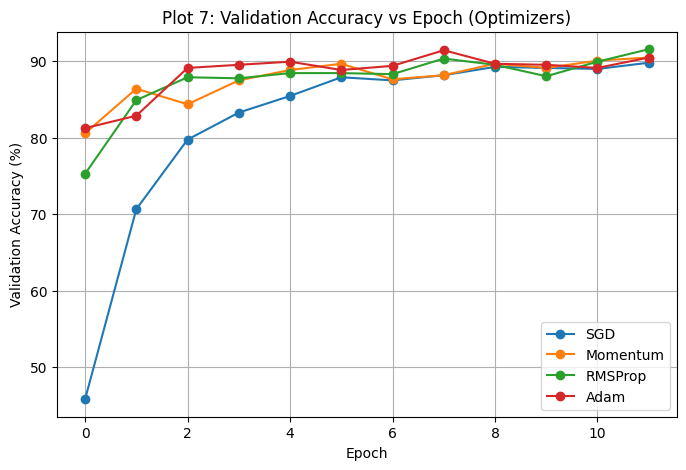

Best optimizer: RMSProp


In [24]:
# Plot 7: Validation Accuracy vs Epoch for Different Optimizers
plt.figure(figsize=(8, 5))
for name in optimizer_configs:
    plt.plot(opt_histories[name]["val_acc"], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 7: Validation Accuracy vs Epoch (Optimizers)")
plt.legend()
plt.grid(True)
plt.show()

best_optimizer = opt_summary_df.loc[opt_summary_df["Best Val. Accuracy (%)"].idxmax(), "Optimizer"]
print("Best optimizer:", best_optimizer)


#### Task 6: CNN Hyperparameter Tuning

Following the **one-hyperparameter-at-a-time** rule, we vary Learning Rate, Batch Size and
Dropout Rate independently (keeping the rest fixed at `he` init, Adam optimizer,
batch size 32, dropout 0.5) and record final validation accuracy on the full
training/validation split.

For reference, the output size of a convolution is
$$O = \left\lfloor \frac{N + 2P - K}{S} \right\rfloor + 1$$
where $N$ is input size, $K$ is kernel size, $P$ is padding and $S$ is stride -- this
determines how kernel size/stride/padding/pooling choices shrink the feature maps inside
MobileNetV2's convolutional blocks.


In [25]:
HP_EPOCHS = 8

# ---- Learning Rate sweep ----
lr_values = [1e-3, 1e-4]
lr_results = {}
for lr in lr_values:
    print(f"Learning rate = {lr}")
    model = build_model(init_method="he", dropout=0.5, use_bn=False, freeze_base=True)
    optimizer = make_optimizer(model, name="adam", lr=lr)
    history, elapsed = train_eval(model, optimizer, train_loader, val_loader, HP_EPOCHS)
    lr_results[lr] = history["val_acc"][-1]
    print(f"  -> final val_acc={history['val_acc'][-1]:.2f}%\n")
    free_memory(model, optimizer)

print(lr_results)


Learning rate = 0.001
  -> final val_acc=89.27%

Learning rate = 0.0001
  -> final val_acc=86.68%

{0.001: 89.2663043478261, 0.0001: 86.68478260869566}


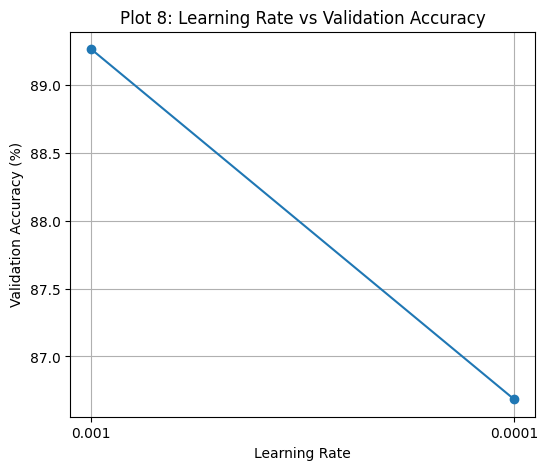

Best learning rate: 0.001


In [26]:
# Plot 8: Learning Rate vs Validation Accuracy
plt.figure(figsize=(6, 5))
plt.plot([str(lr) for lr in lr_values], [lr_results[lr] for lr in lr_values], marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.grid(True)
plt.show()

best_lr = max(lr_results, key=lr_results.get)
print("Best learning rate:", best_lr)


In [27]:
# ---- Batch Size sweep ----
batch_size_values = [16, 32, 64]
bs_results = {}
for bs in batch_size_values:
    print(f"Batch size = {bs}")
    bs_train_loader = DataLoader(train_subset_full, batch_size=bs, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    bs_val_loader = DataLoader(val_subset_full, batch_size=bs, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    model = build_model(init_method="he", dropout=0.5, use_bn=False, freeze_base=True)
    optimizer = make_optimizer(model, name="adam", lr=best_lr)
    history, elapsed = train_eval(model, optimizer, bs_train_loader, bs_val_loader, HP_EPOCHS)
    bs_results[bs] = history["val_acc"][-1]
    print(f"  -> final val_acc={history['val_acc'][-1]:.2f}%\n")

    free_memory(model, optimizer, bs_train_loader, bs_val_loader)

print(bs_results)


Batch size = 16
  -> final val_acc=88.72%

Batch size = 32
  -> final val_acc=88.72%

Batch size = 64
  -> final val_acc=90.08%

{16: 88.72282608695652, 32: 88.72282608695652, 64: 90.08152173913044}


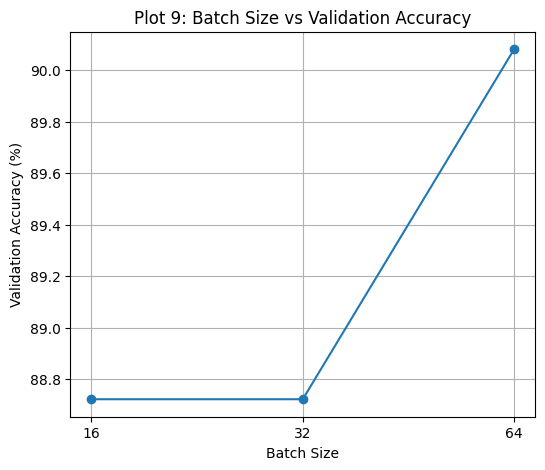

Best batch size: 64


In [28]:
# Plot 9: Batch Size vs Validation Accuracy
plt.figure(figsize=(6, 5))
plt.plot([str(b) for b in batch_size_values], [bs_results[b] for b in batch_size_values], marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.grid(True)
plt.show()

best_batch_size = max(bs_results, key=bs_results.get)
print("Best batch size:", best_batch_size)


In [29]:
# ---- Dropout Rate sweep ----
dropout_values = [0.0, 0.25, 0.5]
dropout_results = {}
for dr in dropout_values:
    print(f"Dropout rate = {dr}")
    model = build_model(init_method="he", dropout=dr, use_bn=False, freeze_base=True)
    optimizer = make_optimizer(model, name="adam", lr=best_lr)
    history, elapsed = train_eval(model, optimizer, train_loader, val_loader, HP_EPOCHS)
    dropout_results[dr] = history["val_acc"][-1]
    print(f"  -> final val_acc={history['val_acc'][-1]:.2f}%\n")
    free_memory(model, optimizer)

print(dropout_results)


Dropout rate = 0.0
  -> final val_acc=88.59%

Dropout rate = 0.25
  -> final val_acc=88.72%

Dropout rate = 0.5
  -> final val_acc=90.22%

{0.0: 88.58695652173913, 0.25: 88.72282608695652, 0.5: 90.21739130434783}


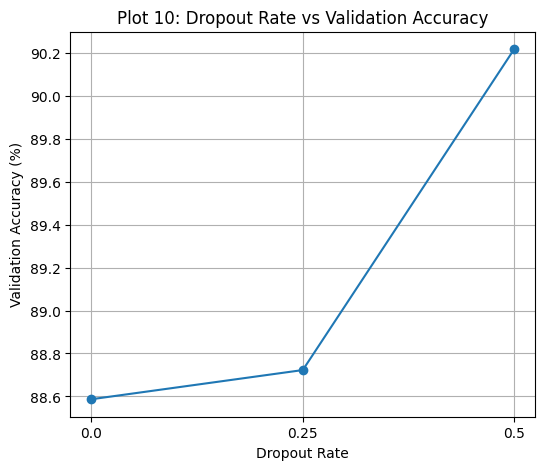

Best dropout rate: 0.5


In [30]:
# Plot 10: Dropout Rate vs Validation Accuracy
plt.figure(figsize=(6, 5))
plt.plot([str(d) for d in dropout_values], [dropout_results[d] for d in dropout_values], marker='o')
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.grid(True)
plt.show()

best_dropout = max(dropout_results, key=dropout_results.get)
print("Best dropout rate:", best_dropout)


#### Task 7: Transfer Learning and Fine-Tuning

Using the best settings found above (`he` init, Adam, `best_lr`, `best_dropout`), we run
the two-stage transfer-learning workflow on the **full** training/validation split:

- **Case A -- Feature Extraction:** MobileNetV2 base is frozen; only the new classifier
  head is trained.
- **Case B -- Fine-Tuning:** the last few convolutional blocks are unfrozen and trained
  jointly with the head, using a much smaller learning rate so the pretrained ImageNet
  features are only gently adjusted rather than destroyed.

In [31]:
FE_EPOCHS = 10
FT_EPOCHS = 6
FT_LR = 1e-5   # smaller than the feature-extraction LR

# ---- Case A: Feature Extraction ----
print("Case A: Feature Extraction (frozen base)")
tl_model = build_model(init_method="he", dropout=best_dropout, use_bn=False, freeze_base=True)
fe_optimizer = make_optimizer(tl_model, name="adam", lr=best_lr)

fe_history, fe_time = train_eval(tl_model, fe_optimizer, train_loader, val_loader, FE_EPOCHS, verbose=True)
accuracy_before_finetune = fe_history["val_acc"][-1]
print(f"\nValidation Accuracy Before Fine-Tuning: {accuracy_before_finetune:.2f}%")

free_memory(fe_optimizer)


Case A: Feature Extraction (frozen base)
  Epoch 1/10 | train_loss=2.348 train_acc=36.14% | val_loss=0.849 val_acc=81.25%
  Epoch 2/10 | train_loss=1.138 train_acc=65.15% | val_loss=0.544 val_acc=84.24%
  Epoch 3/10 | train_loss=0.844 train_acc=74.25% | val_loss=0.437 val_acc=86.41%
  Epoch 4/10 | train_loss=0.713 train_acc=77.85% | val_loss=0.381 val_acc=87.91%
  Epoch 5/10 | train_loss=0.639 train_acc=79.52% | val_loss=0.337 val_acc=89.40%
  Epoch 6/10 | train_loss=0.564 train_acc=81.90% | val_loss=0.327 val_acc=89.40%
  Epoch 7/10 | train_loss=0.498 train_acc=83.59% | val_loss=0.302 val_acc=90.22%
  Epoch 8/10 | train_loss=0.464 train_acc=84.85% | val_loss=0.302 val_acc=90.35%
  Epoch 9/10 | train_loss=0.429 train_acc=85.94% | val_loss=0.301 val_acc=91.85%
  Epoch 10/10 | train_loss=0.415 train_acc=86.68% | val_loss=0.301 val_acc=89.54%

Validation Accuracy Before Fine-Tuning: 89.54%


In [32]:
# ---- Case B: Fine-Tuning ----
print("Case B: Fine-Tuning (unfreeze last 3 feature blocks)")
tl_model.unfreeze_last_n_blocks(n=3)
print("Trainable parameters after unfreezing:", tl_model.trainable_parameter_count())

ft_optimizer = make_optimizer(tl_model, name="adam", lr=FT_LR)
ft_history, ft_time = train_eval(tl_model, ft_optimizer, train_loader, val_loader, FT_EPOCHS, verbose=True)

accuracy_after_finetune = ft_history["val_acc"][-1]
print(f"\nValidation Accuracy Before Fine-Tuning: {accuracy_before_finetune:.2f}%")
print(f"Validation Accuracy After Fine-Tuning : {accuracy_after_finetune:.2f}%")


Case B: Fine-Tuning (unfreeze last 3 feature blocks)
Trainable parameters after unfreezing: 1543525
  Epoch 1/6 | train_loss=0.327 train_acc=88.72% | val_loss=0.282 val_acc=90.76%
  Epoch 2/6 | train_loss=0.312 train_acc=90.18% | val_loss=0.276 val_acc=91.17%
  Epoch 3/6 | train_loss=0.288 train_acc=90.69% | val_loss=0.270 val_acc=91.30%
  Epoch 4/6 | train_loss=0.275 train_acc=90.96% | val_loss=0.266 val_acc=91.30%
  Epoch 5/6 | train_loss=0.268 train_acc=90.56% | val_loss=0.265 val_acc=91.03%
  Epoch 6/6 | train_loss=0.241 train_acc=92.36% | val_loss=0.261 val_acc=90.90%

Validation Accuracy Before Fine-Tuning: 89.54%
Validation Accuracy After Fine-Tuning : 90.90%


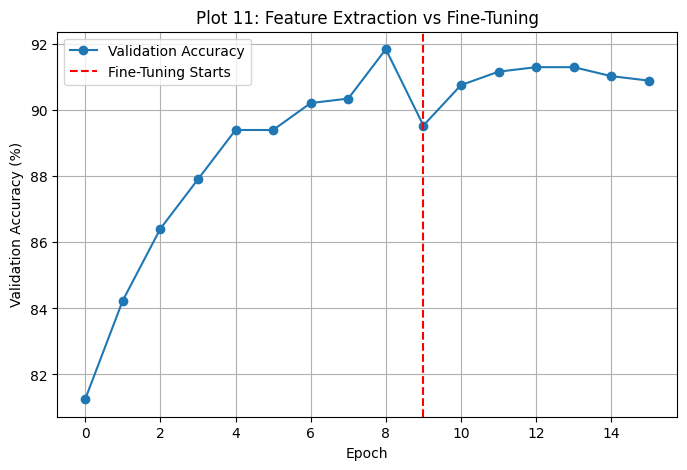

In [33]:
# Combine the two training phases for plotting
combined_train_acc = fe_history["train_acc"] + ft_history["train_acc"]
combined_val_acc   = fe_history["val_acc"] + ft_history["val_acc"]
combined_train_loss = fe_history["train_loss"] + ft_history["train_loss"]
combined_val_loss   = fe_history["val_loss"] + ft_history["val_loss"]
fe_ft_boundary = FE_EPOCHS - 1

# Plot 11: Feature Extraction vs Fine-Tuning (Validation Accuracy across both phases)
plt.figure(figsize=(8, 5))
plt.plot(combined_val_acc, marker='o', label="Validation Accuracy")
plt.axvline(x=fe_ft_boundary, color='red', linestyle='--', label='Fine-Tuning Starts')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 11: Feature Extraction vs Fine-Tuning")
plt.legend()
plt.grid(True)
plt.show()


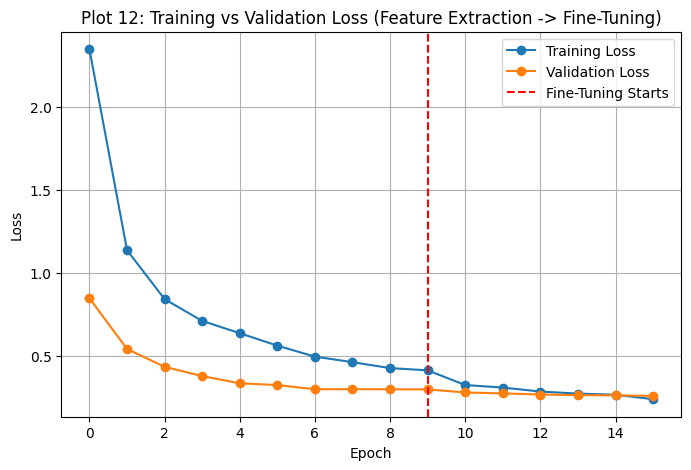

In [34]:
# Plot 12: Training and Validation Loss (before / after fine-tuning)
plt.figure(figsize=(8, 5))
plt.plot(combined_train_loss, marker='o', label="Training Loss")
plt.plot(combined_val_loss, marker='o', label="Validation Loss")
plt.axvline(x=fe_ft_boundary, color='red', linestyle='--', label='Fine-Tuning Starts')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 12: Training vs Validation Loss (Feature Extraction -> Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()

# We no longer need this exploratory model -- the final model is retrained from scratch in Section 12
free_memory(tl_model, ft_optimizer)


#### Task 8: K-Fold Cross-Validation

We select four promising configurations based on the studies above and evaluate each with
**5-fold cross-validation** on the full training data (`train_idx`), kept completely
separate from the independent held-out test set. Each fold trains a fresh model from
scratch (memory is freed between every fold and every configuration) so that no leftover
model/optimizer accumulates in GPU memory across the 4 configurations x 5 folds = 20
fold-training runs.


In [35]:
CV_FOLDS = 5
CV_EPOCHS = 8

cv_pool_idx = np.array(train_idx)
print("Cross-validation pool size (full training set):", len(cv_pool_idx))

# Four candidate configurations, informed by Sections 2, 3, 5 and 6
candidate_configs = {
    "C1_Baseline":          dict(init="random", dropout=0.5, use_bn=False, optimizer="adam",   lr=1e-3),
    "C2_BestInit":          dict(init=best_init, dropout=0.5, use_bn=False, optimizer="adam",   lr=1e-3),
    "C3_BestInit_BestReg":  dict(init=best_init, dropout=best_dropout, use_bn=(best_reg=="BatchNorm"),
                                  optimizer="adam", lr=1e-3),
    "C4_AllBest":           dict(init=best_init, dropout=best_dropout, use_bn=(best_reg=="BatchNorm"),
                                  optimizer=best_optimizer.lower().replace(" ", ""), lr=best_lr),
}
# Guard against an optimizer name mismatch (e.g. "Momentum" -> "momentum")
_opt_name_map = {"sgd": "sgd", "momentum": "momentum", "rmsprop": "rmsprop", "adam": "adam"}
candidate_configs["C4_AllBest"]["optimizer"] = _opt_name_map.get(
    candidate_configs["C4_AllBest"]["optimizer"], "adam"
)

for name, cfg in candidate_configs.items():
    print(name, "->", cfg)


Cross-validation pool size (full training set): 2944
C1_Baseline -> {'init': 'random', 'dropout': 0.5, 'use_bn': False, 'optimizer': 'adam', 'lr': 0.001}
C2_BestInit -> {'init': 'xavier', 'dropout': 0.5, 'use_bn': False, 'optimizer': 'adam', 'lr': 0.001}
C3_BestInit_BestReg -> {'init': 'xavier', 'dropout': 0.5, 'use_bn': False, 'optimizer': 'adam', 'lr': 0.001}
C4_AllBest -> {'init': 'xavier', 'dropout': 0.5, 'use_bn': False, 'optimizer': 'rmsprop', 'lr': 0.001}


In [36]:
def kfold_cv(config, pool_indices, k=5, epochs=5):
    """Run k-fold cross-validation for a single configuration.
    Returns a list of per-fold final validation accuracies."""
    kf = KFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_accuracies = []

    for fold_num, (tr_pos, va_pos) in enumerate(kf.split(pool_indices), start=1):
        fold_train_idx = pool_indices[tr_pos].tolist()
        fold_val_idx = pool_indices[va_pos].tolist()

        fold_train_loader = DataLoader(Subset(train_dataset_full, fold_train_idx),
                                        batch_size=BATCH_SIZE, shuffle=True,
                                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        fold_val_loader = DataLoader(Subset(eval_dataset_full, fold_val_idx),
                                      batch_size=BATCH_SIZE, shuffle=False,
                                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

        model = build_model(init_method=config["init"], dropout=config["dropout"],
                             use_bn=config["use_bn"], freeze_base=True)
        optimizer = make_optimizer(model, name=config["optimizer"], lr=config["lr"])

        history, _ = train_eval(model, optimizer, fold_train_loader, fold_val_loader, epochs)
        fold_accuracies.append(history["val_acc"][-1])
        print(f"    Fold {fold_num}: val_acc={history['val_acc'][-1]:.2f}%")

        free_memory(model, optimizer, fold_train_loader, fold_val_loader)

    return fold_accuracies


In [37]:
cv_results = {}
for name, cfg in candidate_configs.items():
    print(f"Cross-validating '{name}'...")
    accs = kfold_cv(cfg, cv_pool_idx, k=CV_FOLDS, epochs=CV_EPOCHS)
    cv_results[name] = accs
    print(f"  -> mean={np.mean(accs):.2f}% sd={np.std(accs):.2f}\n")


Cross-validating 'C1_Baseline'...
    Fold 1: val_acc=9.34%
    Fold 2: val_acc=9.68%
    Fold 3: val_acc=8.66%
    Fold 4: val_acc=6.28%
    Fold 5: val_acc=9.86%
  -> mean=8.76% sd=1.31

Cross-validating 'C2_BestInit'...
    Fold 1: val_acc=86.08%
    Fold 2: val_acc=88.96%
    Fold 3: val_acc=87.61%
    Fold 4: val_acc=88.79%
    Fold 5: val_acc=83.67%
  -> mean=87.02% sd=1.97

Cross-validating 'C3_BestInit_BestReg'...
    Fold 1: val_acc=89.13%
    Fold 2: val_acc=88.79%
    Fold 3: val_acc=86.93%
    Fold 4: val_acc=86.76%
    Fold 5: val_acc=86.56%
  -> mean=87.64% sd=1.10

Cross-validating 'C4_AllBest'...
    Fold 1: val_acc=86.76%
    Fold 2: val_acc=87.10%
    Fold 3: val_acc=85.06%
    Fold 4: val_acc=86.42%
    Fold 5: val_acc=84.86%
  -> mean=86.04% sd=0.91



In [38]:
# Cross-validation results table
cv_table_rows = []
for name, accs in cv_results.items():
    row = {"Configuration": name}
    for i, a in enumerate(accs, start=1):
        row[f"F{i}"] = round(a, 2)
    row["Mean"] = round(np.mean(accs), 2)
    row["SD"] = round(np.std(accs), 2)
    cv_table_rows.append(row)

cv_table_df = pd.DataFrame(cv_table_rows)
cv_table_df


,Configuration,F1,F2,F3,F4,F5,Mean,SD
0,C1_Baseline,9.34,9.68,8.66,6.28,9.86,8.76,1.31
1,C2_BestInit,86.08,88.96,87.61,88.79,83.67,87.02,1.97
2,C3_BestInit_BestReg,89.13,88.79,86.93,86.76,86.56,87.64,1.10
3,C4_AllBest,86.76,87.10,85.06,86.42,84.86,86.04,0.91


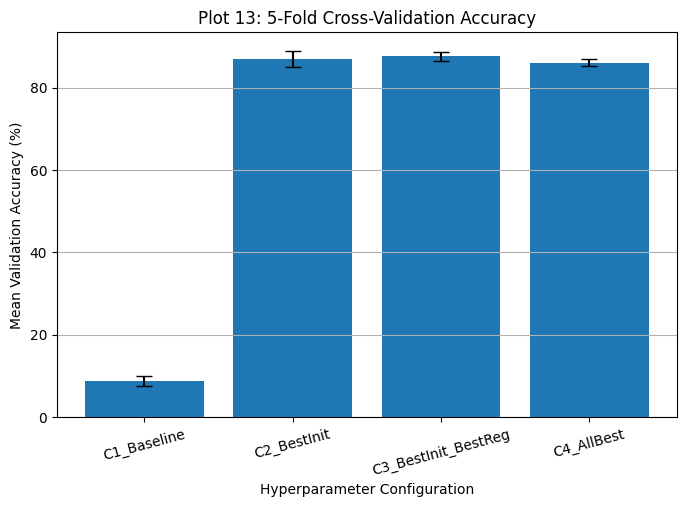

Selected configuration (highest mean CV accuracy): C3_BestInit_BestReg
Mean +/- SD : 87.64 +/- 1.10


In [39]:
# Plot 13: 5-Fold Cross-Validation Accuracy (mean +/- SD)
names = list(cv_results.keys())
means = [np.mean(cv_results[n]) for n in names]
sds = [np.std(cv_results[n]) for n in names]

plt.figure(figsize=(8, 5))
plt.bar(names, means, yerr=sds, capsize=6)
plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy")
plt.xticks(rotation=15)
plt.grid(True, axis='y')
plt.show()

best_config_name = max(cv_results, key=lambda n: np.mean(cv_results[n]))
print("Selected configuration (highest mean CV accuracy):", best_config_name)
print("Mean +/- SD :", f"{np.mean(cv_results[best_config_name]):.2f} +/- {np.std(cv_results[best_config_name]):.2f}")


#### Task 9: Final Model Evaluation

The configuration selected by cross-validation is retrained on the **complete** training
data (train + validation split combined) with the same two-stage feature-extraction ->
fine-tuning workflow as Section 7, then evaluated **once** on the untouched test set.

In [40]:
best_config = candidate_configs[best_config_name]
print("Final configuration:", best_config)

FINAL_FE_EPOCHS = 15
FINAL_FT_EPOCHS = 8

# Combine train + validation indices for the final fit (test set stays untouched)
final_train_indices = train_idx + val_idx
final_train_loader = DataLoader(Subset(train_dataset_full, final_train_indices),
                                 batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

final_model = build_model(init_method=best_config["init"], dropout=best_config["dropout"],
                           use_bn=best_config["use_bn"], freeze_base=True)
final_total_params = final_model.total_parameter_count()

final_start_time = time.time()

# Stage A: feature extraction on full data
optimizer_a = make_optimizer(final_model, name=best_config["optimizer"], lr=best_config["lr"])
final_fe_history, _ = train_eval(final_model, optimizer_a, final_train_loader, val_loader,
                                  FINAL_FE_EPOCHS, verbose=True)
free_memory(optimizer_a)

# Stage B: fine-tuning on full data
final_model.unfreeze_last_n_blocks(n=3)
optimizer_b = make_optimizer(final_model, name=best_config["optimizer"], lr=1e-5)
final_ft_history, _ = train_eval(final_model, optimizer_b, final_train_loader, val_loader,
                                  FINAL_FT_EPOCHS, verbose=True)

final_training_time = time.time() - final_start_time
print(f"\nTotal final-model training time: {final_training_time:.1f}s")

free_memory(optimizer_b, final_train_loader)


Final configuration: {'init': 'xavier', 'dropout': 0.5, 'use_bn': False, 'optimizer': 'adam', 'lr': 0.001}
  Epoch 1/15 | train_loss=2.080 train_acc=41.85% | val_loss=0.588 val_acc=89.54%
  Epoch 2/15 | train_loss=0.967 train_acc=69.84% | val_loss=0.368 val_acc=90.35%
  Epoch 3/15 | train_loss=0.726 train_acc=77.04% | val_loss=0.246 val_acc=94.29%
  Epoch 4/15 | train_loss=0.618 train_acc=80.30% | val_loss=0.220 val_acc=93.34%
  Epoch 5/15 | train_loss=0.560 train_acc=81.88% | val_loss=0.182 val_acc=95.92%
  Epoch 6/15 | train_loss=0.489 train_acc=84.29% | val_loss=0.180 val_acc=93.89%
  Epoch 7/15 | train_loss=0.453 train_acc=84.81% | val_loss=0.138 val_acc=96.47%
  Epoch 8/15 | train_loss=0.413 train_acc=85.68% | val_loss=0.137 val_acc=95.79%
  Epoch 9/15 | train_loss=0.373 train_acc=87.26% | val_loss=0.113 val_acc=97.28%
  Epoch 10/15 | train_loss=0.363 train_acc=87.85% | val_loss=0.101 val_acc=97.28%
  Epoch 11/15 | train_loss=0.356 train_acc=88.26% | val_loss=0.112 val_acc=97.15%


In [41]:
# Evaluate the final model on the held-out TEST set (used only now, for the first time)
final_model.eval()
all_predictions, all_labels_list = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        preds = outputs.argmax(dim=1)
        all_predictions.extend(preds.cpu().numpy().tolist())
        all_labels_list.extend(labels.cpu().numpy().tolist())

all_predictions = np.array(all_predictions)
all_labels_arr = np.array(all_labels_list)

test_accuracy = 100.0 * (all_predictions == all_labels_arr).mean()
precision = precision_score(all_labels_arr, all_predictions, average="weighted", zero_division=0)
recall = recall_score(all_labels_arr, all_predictions, average="weighted", zero_division=0)
f1 = f1_score(all_labels_arr, all_predictions, average="weighted", zero_division=0)

final_mean_cv_acc = np.mean(cv_results[best_config_name])
final_cv_sd = np.std(cv_results[best_config_name])

final_report_table = pd.DataFrame([{
    "Mean CV Accuracy (%)": round(final_mean_cv_acc, 2),
    "CV Standard Deviation": round(final_cv_sd, 2),
    "Test Accuracy (%)": round(test_accuracy, 2),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4),
    "Training Time (s)": round(final_training_time, 1),
    "Number of Parameters": final_total_params,
}])
final_report_table


,Mean CV Accuracy (%),CV Standard Deviation,Test Accuracy (%),Precision,Recall,F1-score,Training Time (s),Number of Parameters
0,87.64,1.1,88.36,0.8872,0.8836,0.8836,295.9,2561317


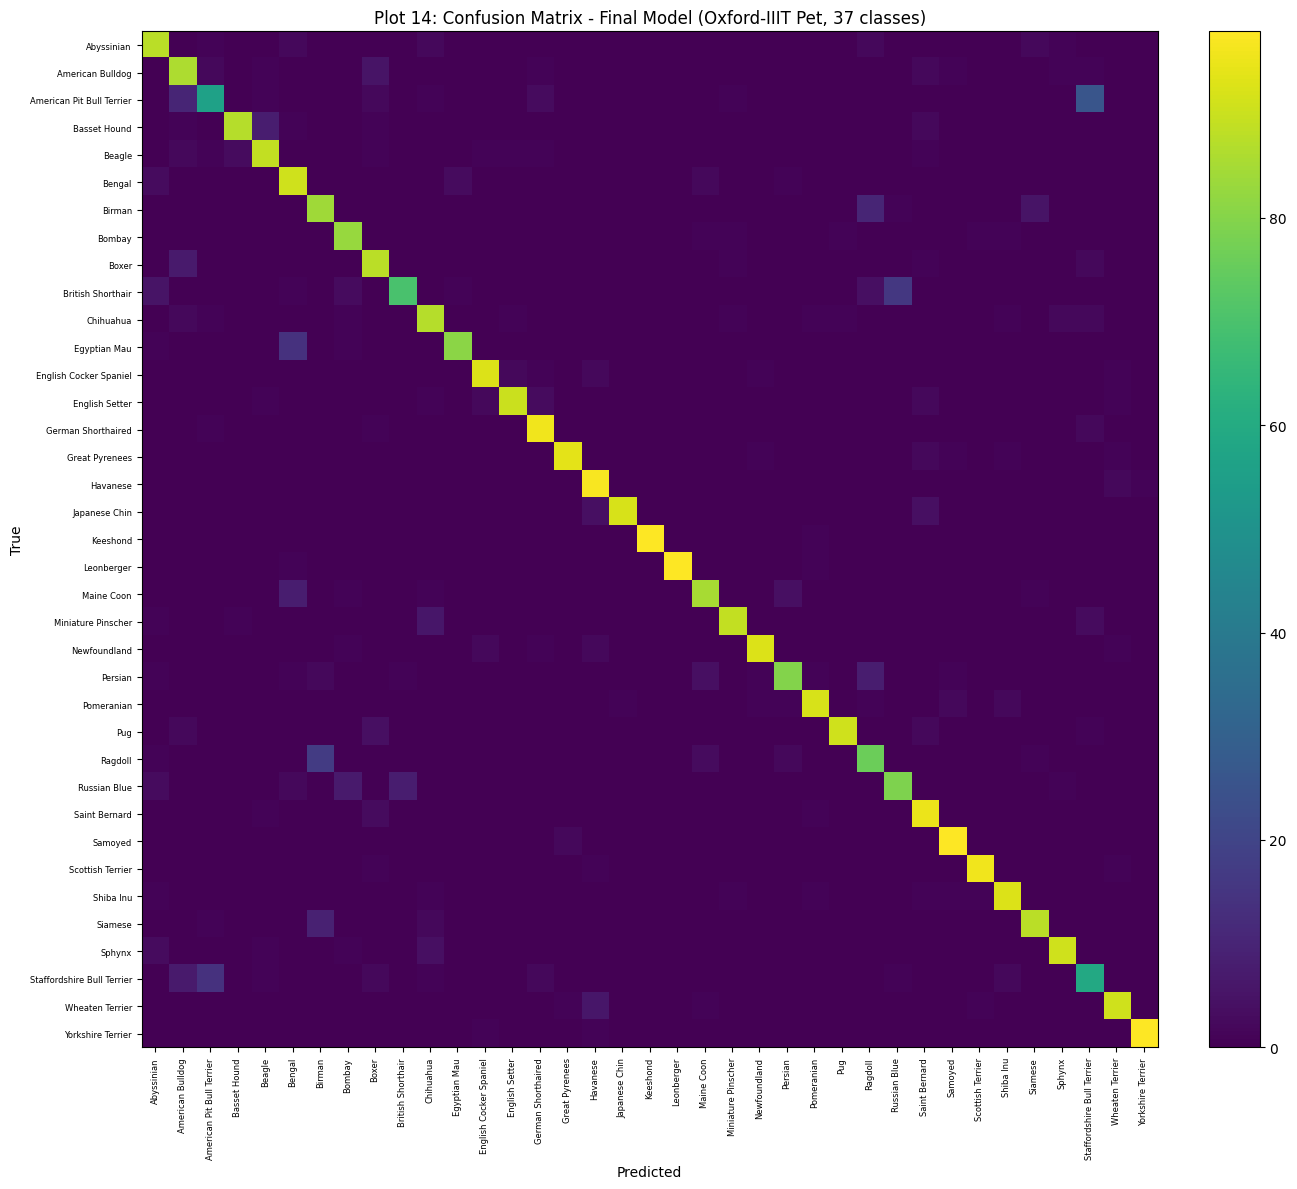

In [42]:
# Plot 14: Confusion Matrix (37 classes)
cm = confusion_matrix(all_labels_arr, all_predictions)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="viridis")
plt.title("Plot 14: Confusion Matrix - Final Model (Oxford-IIIT Pet, 37 classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(num_classes), classes, rotation=90, fontsize=6)
plt.yticks(range(num_classes), classes, fontsize=6)
plt.tight_layout()
plt.show()


In [43]:
# Identify best-classified and most-confused classes
per_class_acc = cm.diagonal() / cm.sum(axis=1)
class_acc_df = pd.DataFrame({"Class": classes, "Recall (per-class accuracy)": per_class_acc})
class_acc_df = class_acc_df.sort_values("Recall (per-class accuracy)", ascending=False)

print("Best classified classes:")
print(class_acc_df.head(5).to_string(index=False))
print("\nMost poorly classified classes:")
print(class_acc_df.tail(5).to_string(index=False))

# Most frequently confused class pairs (off-diagonal)
cm_off_diag = cm.copy().astype(float)
np.fill_diagonal(cm_off_diag, 0)
top_confusions = []
flat_idx = np.dstack(np.unravel_index(np.argsort(cm_off_diag.ravel())[::-1][:5], cm_off_diag.shape))[0]
for true_i, pred_i in flat_idx:
    if cm_off_diag[true_i, pred_i] > 0:
        top_confusions.append((classes[true_i], classes[pred_i], int(cm[true_i, pred_i])))

print("\nTop confused (true -> predicted) class pairs:")
for t, p, c in top_confusions:
    print(f"  {t}  ->  {p}   ({c} images)")


Best classified classes:
            Class  Recall (per-class accuracy)
         Keeshond                     0.989899
Yorkshire Terrier                     0.980000
          Samoyed                     0.980000
       Leonberger                     0.980000
         Havanese                     0.970000

Most poorly classified classes:
                     Class  Recall (per-class accuracy)
              Russian Blue                     0.790000
                   Ragdoll                     0.760000
         British Shorthair                     0.700000
Staffordshire Bull Terrier                     0.662921
 American Pit Bull Terrier                     0.560000

Top confused (true -> predicted) class pairs:
  American Pit Bull Terrier  ->  Staffordshire Bull Terrier   (26 images)
  Ragdoll  ->  Birman   (17 images)
  British Shorthair  ->  Russian Blue   (16 images)
  Staffordshire Bull Terrier  ->  American Pit Bull Terrier   (14 images)
  Egyptian Mau  ->  Bengal   (14 images)


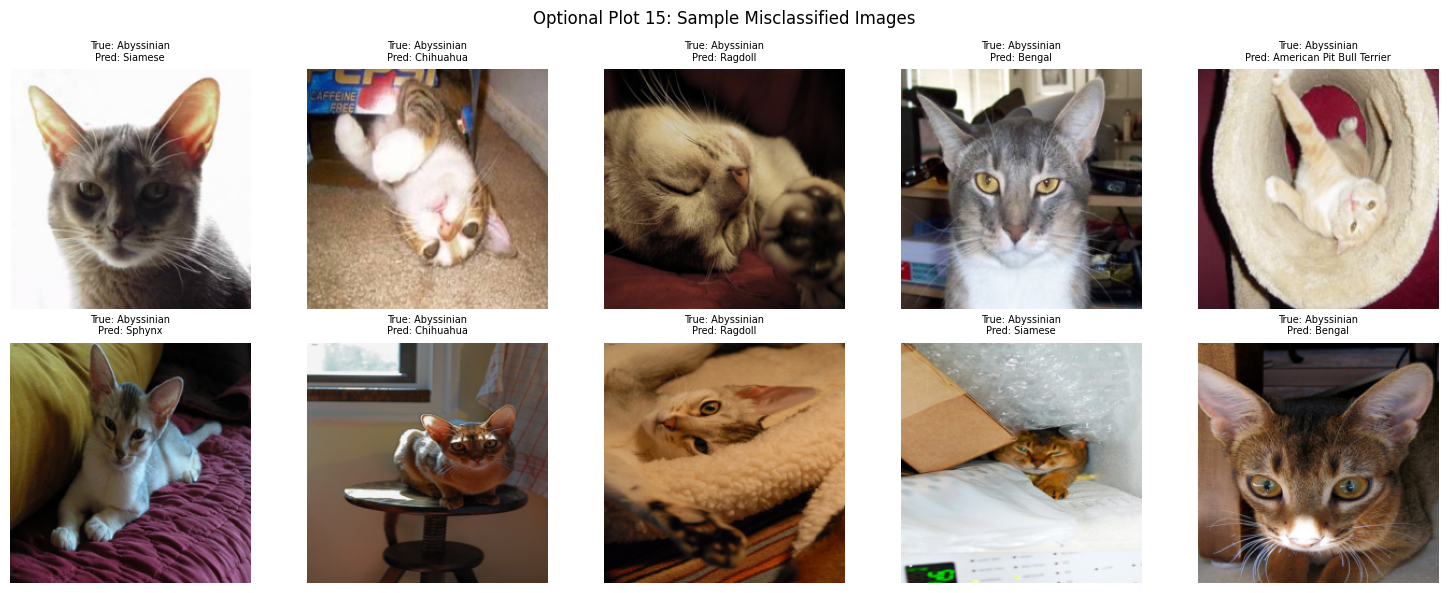

In [44]:
# Optional Plot 15: Misclassified Images
misclassified_indices = np.where(all_predictions != all_labels_arr)[0][:10]

# Display-friendly (unnormalized) view of the same test images, indexed identically to test_dataset
test_display_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="test", target_types="category", transform=display_transform
)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(misclassified_indices):
    image, true_label = test_display_dataset[idx]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"True: {classes[true_label]}\nPred: {classes[all_predictions[idx]]}", fontsize=7)
    plt.axis("off")
plt.suptitle("Optional Plot 15: Sample Misclassified Images")
plt.tight_layout()
plt.show()


#### Overall Results

A consolidated view of every major stage of the study. "CV Accuracy"/"SD"/"Test Accuracy"
are only meaningfully available for the final, cross-validated model; earlier rows report
the validation accuracy obtained in their own section (trained on the full dataset) for
comparison.


In [45]:
overall_rows = [
    {"Configuration": "Baseline (random init, no reg., Adam)",
     "Validation/CV Accuracy (%)": round(init_histories["random"]["val_acc"][-1], 2),
     "SD": "-", "Test Accuracy (%)": "-", "Training Time (s)": "-"},

    {"Configuration": f"Best Initialization ({best_init})",
     "Validation/CV Accuracy (%)": round(init_histories[best_init]["val_acc"][-1], 2),
     "SD": "-", "Test Accuracy (%)": "-", "Training Time (s)": "-"},

    {"Configuration": f"Best Regularization ({best_reg})",
     "Validation/CV Accuracy (%)": round(reg_histories[best_reg]["val_acc"][-1], 2),
     "SD": "-", "Test Accuracy (%)": "-", "Training Time (s)": "-"},

    {"Configuration": f"Best Optimizer ({best_optimizer})",
     "Validation/CV Accuracy (%)": round(max(opt_histories[best_optimizer]["val_acc"]), 2),
     "SD": "-", "Test Accuracy (%)": "-", "Training Time (s)": "-"},

    {"Configuration": f"Best Hyperparameters (lr={best_lr}, bs={best_batch_size}, dropout={best_dropout})",
     "Validation/CV Accuracy (%)": round(dropout_results[best_dropout], 2),
     "SD": "-", "Test Accuracy (%)": "-", "Training Time (s)": "-"},

    {"Configuration": f"Fine-Tuned Model ({best_config_name}, selected by 5-fold CV)",
     "Validation/CV Accuracy (%)": round(final_mean_cv_acc, 2),
     "SD": round(final_cv_sd, 2),
     "Test Accuracy (%)": round(test_accuracy, 2),
     "Training Time (s)": round(final_training_time, 1)},
]

overall_results_df = pd.DataFrame(overall_rows)
overall_results_df


,Configuration,Validation/CV Accuracy (%),SD,Test Accuracy (%),Training Time (s)
0,"Baseline (random init, no reg., Adam)",5.84,-,-,-
1,Best Initialization (xavier),90.08,-,-,-
2,Best Regularization (Dropout),88.72,-,-,-
3,Best Optimizer (RMSProp),91.58,-,-,-
4,"Best Hyperparameters (lr=0.001, bs=64, dropout...",90.22,-,-,-
5,"Fine-Tuned Model (C3_BestInit_BestReg, selecte...",87.64,1.1,88.36,295.9
